In [24]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
os.makedirs("outputs", exist_ok=True)

import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path

# The standard device check — you'll use this pattern in every PyTorch notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128


# Tensor

## Q1

In [25]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)
print(f'A shape: {a.shape}, dtype: {a.dtype}, device: {a.device}')
print(f'B shape: {b.shape}, dtype: {b.dtype}, device: {b.device}')
print(f'C shape: {c.shape}, dtype: {c.dtype}, device: {c.device}')

A shape: torch.Size([2, 3]), dtype: torch.float32, device: cpu
B shape: torch.Size([2, 3]), dtype: torch.float32, device: cpu
C shape: torch.Size([4]), dtype: torch.float32, device: cpu


All of these tensors are working on a CPU. To run the model on a GPU, the tensors had to be moved to the GPU; otherwise, it would raise an error because we cannot run a model connecting 2 seperate devices.

## Q2

In [26]:
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])
x_sqr = torch.sqrt(x)
x_sum = x.sum()
x_mean = x.mean()
x_argmax = x.argmax()
print(f'Sqrt: {x_sqr}, Sum: {x_sum}, Mean: {x_mean}, Argmax: {x_argmax}')

Sqrt: tensor([1., 2., 3., 4., 5.]), Sum: 55.0, Mean: 11.0, Argmax: 4


It will give an index of the highest performing class out of 1000

## Q3

In [27]:
a_gpu   = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

a_back  = a_gpu.cpu()
a_numpy = a_back.numpy()
print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


PyTorch requires .cpu() before calling numpy() because otherwise they would be on different devices. Which tells that NymPy lives in CPU space. 

## Q4

In [28]:
t = torch.arange(24).float()
t1 = t.reshape(4, 6)
print(f'Shape (4, 6): {t1.shape}')
t2 = t.reshape(2, 3, 4)
print(f'Shape (2, 3, 4): {t2.shape}')
t3 = t1.unsqueeze(0)
print(f'Shape new dim: {t3.shape}')


Shape (4, 6): torch.Size([4, 6])
Shape (2, 3, 4): torch.Size([2, 3, 4])
Shape new dim: torch.Size([1, 4, 6])


Adding a new dimension at position 0 would help convert the image to the right shape, because even if there's only one image given to the neural network, it still expects to see a certain size

## Q5

In [29]:
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a  = torch.tensor(np_a, dtype=torch.float32)
t_b  = torch.tensor(np_b, dtype=torch.float32)

npy_r = np_a@np_b
print(f'NumPy:\n{npy_r}')
pyt_r = t_a@t_b
print(f'PyTorch:\n{pyt_r}')

NumPy:
[[19. 22.]
 [43. 50.]]
PyTorch:
tensor([[19., 22.],
        [43., 50.]])


If input included multiple features, matrix multiplication helps produce multiple outputs in one step.

# Model

## Q1

In [30]:
weights = ResNet18_Weights.DEFAULT
model   = models.resnet18(weights=weights)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters:     11,689,512
Trainable parameters: 11,689,512


Starting with pretrained weights helps to save a lot of resources, including time and money. The model already has basic knowledge and doesn't require training it from scratch for several days. 

## Q2

In [31]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

1. The last layer named 'fc' and the output size is 1000
2. The 'deep' model has multiple layers, after which the model produces the result 

## Q3

In [32]:
model = model.to(device) # The following changes the model to be stored as GPU, so the input and the model would be on one device(they cannot be on separate ones)
model.eval() # It changes the model to a testing mode. Layers that behave differently are dropout and batch normalization
print("Model ready for inference.")

Model ready for inference.


## Q4

In [33]:
preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


The following step transforms the input image into the standard size that the model needs. It takes the image and first resizes it to 256, and then crops the image so it will be 224x224 in size. Then it takes the image and, using ToTensor(), converts it to a PyTorch tensor. Then scales the pixel range to be from 0 to 1. It is not using mean of 0.5 and std of 0.1 to normilize all images in the same way as it been done in the traning mode.

# Inference

In [34]:
import random
random.seed(42)

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    img_path  = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name


imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")

Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


## Q1

In [35]:
def get_top5_predictions(model, preprocess, image, device, class_labels):
    """
    Run inference on a PIL image and return the top-5 predictions.
    Returns a list of (class_name, probability) tuples.
    """
    # Step 1: Preprocess the image and add a batch dimension
    # (hint: use preprocess(), .unsqueeze(0), and .to(device))
    image_tensor = preprocess(image).unsqueeze(0).to(device)

    # Step 2: Run inference inside a torch.no_grad() block
    # (hint: call model() on your input tensor to get output of shape (1, 1000))
    with torch.no_grad():
        logits = model(image_tensor)
        
    # Step 3: Convert raw scores (logits) to probabilities
    # (hint: use torch.nn.functional.softmax on output[0])
    probs = torch.nn.functional.softmax(logits[0])

    # Step 4: Get the top 5 predictions using torch.topk
    # (hint: returns top_probs and top_indices)
    top_probs, top_idxs = probs.topk(5)

    # Step 5: Build and return a list of (class_name, probability) tuples
    top_prob = top_probs.squeeze().cpu()
    top_indx = top_idxs.squeeze().cpu()
    pred = []
    for prob, idx in zip(top_prob, top_indx): 
        pred.append((class_labels[idx.item()], prob.item()))
    return pred

In [42]:
img1, img_name = load_sample_image("mountain")
preds         = get_top5_predictions(model, preprocess, img1, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")


Top-5 predictions for '21247.jpg':
  alp                             0.6959
  promontory                      0.1143
  volcano                         0.0587
  valley                          0.0456
  lakeside                        0.0090


/tmp/ipykernel_57/2027774307.py:17: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = torch.nn.functional.softmax(logits[0])


The predictions somewhat make sense. None of this 5 words are outstanding and far from the mountain picture.

## Q2

In [37]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]
    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")


[buildings]  24258.jpg
  palace                          0.4301
  gondola                         0.1305
  monastery                       0.0624

[forest]  23309.jpg
  viaduct                         0.3853
  totem pole                      0.1089
  cliff                           0.0419

[glacier]  20272.jpg
  volcano                         0.3854
  valley                          0.3297
  promontory                      0.1216

[mountain]  20662.jpg
  ski                             0.5933
  alp                             0.3821
  snowmobile                      0.0071

[sea]  23069.jpg
  seashore                        0.2016
  breakwater                      0.1834
  geyser                          0.1718

[street]  24269.jpg
  unicycle                        0.1299
  triumphal arch                  0.1268
  jinrikisha                      0.1049


/tmp/ipykernel_57/2027774307.py:17: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = torch.nn.functional.softmax(logits[0])


The model is most confident about the mountain image, and the least confident is the street or forest label. It could be due to the street and forest having a lot of different details depending on the picture, so it is harder to find a pattern, while mountain images have outstanding details.

## Q3

In [38]:
img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

Logit  range: min=-4.87, max=6.61
Prob   range: min=0.000001, max=0.0979
Probs sum to: 1.000000
Top prediction: mountain bike  (0.0979)


Networks output logits to ensure numerical stability, the probabilities are strictly from 0 to 1, and differences could be very small, so the model fails to learn from it. But in the case when we need to filter out low-confidence predictions, it is better to work with predictions due to the smaller spread, and they are easier to interpret 

## Q4

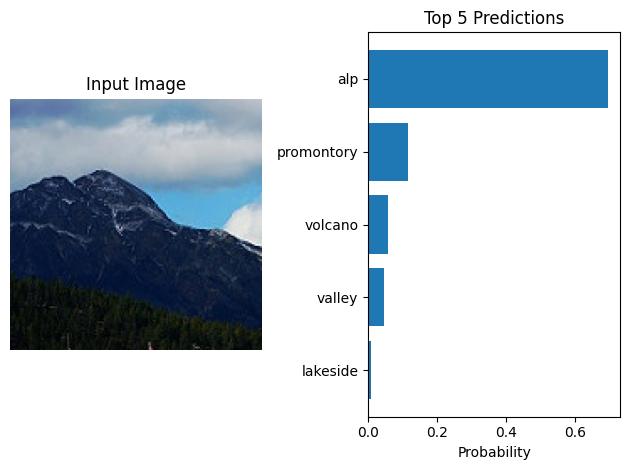

In [43]:
labels = [class_name for class_name, prob in preds]
prob_img = [prob for class_name, prob in preds]

plt.subplot(1, 2, 1)
plt.imshow(img1) 
plt.axis("off") 
plt.title("Input Image")

plt.subplot(1, 2, 2)
plt.barh(labels[::-1], prob_img[::-1])
plt.xlabel("Probability")
plt.title("Top 5 Predictions")

plt.tight_layout()
plt.savefig('outputs/warmup_inference_viz.png')
plt.show()


Showing the image on one side and on the other, a bar plot where predictions with their probabilities would be shown. The labels that are not inside the threshold and need to be reviewed should be marked(in a different color). In terms of what threshold size would be good to be confident in the predictions is from 0.75-0.9, but it would depend on the final result that we want to achieve with this model.